# Stock Market Risk Classification and Prediction Using Machine Learning

In [1]:
# Data Collection:
!pip install yfinance

In [2]:
# Important Libraries

import pandas as pd
import numpy as np 

import yfinance as yf

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Downloading the Stock data

df = yf.download(

    'RELIANCE.NS',
    start = '2025-01-01',
    end = '2026-06-23'
)

[*********************100%***********************]  1 of 1 completed


In [4]:
# Checking most recent trading date available
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2026-06-16,1328.800049,1333.400024,1306.400024,1313.400024,18513223
2026-06-17,1332.699951,1334.000000,1317.000000,1333.000000,10029170
2026-06-18,1328.099976,1333.900024,1322.000000,1330.000000,15494549
2026-06-19,1309.500000,1338.199951,1305.300049,1328.000000,24887034
2026-06-22,1326.500000,1344.900024,1314.099976,1316.699951,12931213


In [5]:
# Check Dataset
df.head()

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276
2025-01-03,1240.437744,1251.244443,1224.921714,1233.249818,15521102
2025-01-06,1207.571411,1251.194681,1204.597097,1243.213557,14816766
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505


In [6]:
df.shape

(366, 5)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 366 entries, 2025-01-01 to 2026-06-22
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   366 non-null    float64
 1   (High, RELIANCE.NS)    366 non-null    float64
 2   (Low, RELIANCE.NS)     366 non-null    float64
 3   (Open, RELIANCE.NS)    366 non-null    float64
 4   (Volume, RELIANCE.NS)  366 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 17.2 KB


In [8]:
df.isnull().sum() # Checking Null Values

Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

In [9]:
df.describe() # Statistical Summary

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,366.000000,366.000000,366.000000,366.000000,3.660000e+02
mean,1378.421275,1390.610216,1366.848422,1378.710706,1.295969e+07
std,98.117972,98.160643,98.997098,98.863256,6.480052e+06
min,1151.951782,1161.221645,1105.304523,1122.505946,0.000000e+00
25%,1310.606232,1333.525024,1304.219816,1315.164552,8.368329e+06
50%,1385.195374,1399.174277,1373.594323,1383.602784,1.133943e+07
75%,1440.895050,1454.350727,1426.877731,1440.708066,1.614834e+07
max,1584.971802,1604.382010,1570.936597,1585.668486,4.263425e+07


In [10]:
# Data Cleaning
df.duplicated().sum() # checking duplicates

np.int64(0)

In [11]:
# If duplicates exists 
## df.drop_duplicates(inplace = True)

In [12]:
# Feature Engineering
# Calculating Daily Returns

df['Return'] = df['Close'].pct_change()


# Meanging:
# Today's Price - Yesterday's Price
# --------------------------------
   #   Yesterday's Price

In [13]:
df[['Close', 'Return']].head(10)

Price,Close,Return
Ticker,RELIANCE.NS,
Date,,
2025-01-01,1210.793579,NaN
2025-01-02,1231.167725,0.016827
2025-01-03,1240.437744,0.007529
2025-01-06,1207.571411,-0.026496
2025-01-07,1230.225708,0.018760
2025-01-08,1254.664795,0.019866
2025-01-09,1244.006714,-0.008495
2025-01-10,1231.266846,-0.010241


In [14]:
# Removing NA values

df.dropna(inplace = True)

In [15]:
# Calculating Z-Score

from scipy.stats import zscore

df['ZScore'] = zscore(df['Return'].dropna())

In [16]:
df[['Return', 'ZScore']].head(10)

Price,Return,ZScore
Ticker,,
Date,,
2025-01-02,0.016827,1.238950
2025-01-03,0.007529,0.540326
2025-01-06,-0.026496,-2.016325
2025-01-07,0.018760,1.384204
2025-01-08,0.019866,1.467257
2025-01-09,-0.008495,-0.663732
2025-01-10,-0.010241,-0.794944
2025-01-13,-0.001651,-0.149471


In [17]:
df.shape

(365, 7)

In [18]:
# Creating Risk Classes

conditions = [

    df['ZScore'] < -1,
    (df['ZScore'] <= -1) & (df['ZScore'] <= 1),
    df['ZScore'] > 1
]

labels = [

    'High Risk',
    'Medium Risk',
    'Low Risk'
]

df['Risk_Class'] = np.select(

    conditions,
    labels,
    default = 'Medium Risk'
)

In [19]:
df['Risk_Class'].value_counts()

Risk_Class
Medium Risk    270
Low Risk        48
High Risk       47
Name: count, dtype: int64

In [20]:
# Verifying the Data Sets that we have Created

df[['Return', 'ZScore', 'Risk_Class']].head(10)

Price,Return,ZScore,Risk_Class
Ticker,,,
Date,,,
2025-01-02,0.016827,1.238950,Low Risk
2025-01-03,0.007529,0.540326,Medium Risk
2025-01-06,-0.026496,-2.016325,High Risk
2025-01-07,0.018760,1.384204,Low Risk
2025-01-08,0.019866,1.467257,Low Risk
2025-01-09,-0.008495,-0.663732,Medium Risk
2025-01-10,-0.010241,-0.794944,Medium Risk
2025-01-13,-0.001651,-0.149471,Medium Risk


In [21]:
df[['Return', 'ZScore', 'Risk_Class']].tail(10)

Price,Return,ZScore,Risk_Class
Ticker,,,
Date,,,
2026-06-09,0.004670,0.325484,Medium Risk
2026-06-10,-0.008194,-0.641137,Medium Risk
2026-06-11,0.003336,0.225266,Medium Risk
2026-06-12,0.023753,1.759359,Low Risk
2026-06-15,0.010828,0.788143,Medium Risk
2026-06-16,0.016679,1.227856,Low Risk
2026-06-17,0.002935,0.195092,Medium Risk
2026-06-18,-0.003452,-0.284791,Medium Risk


In [22]:
# Currently we are able to see the today's risk , zscore and return.
# By using this data we can predict tomorrow's Risk class


In [23]:
# Creating Target Variable
df['Target'] = df['Risk_Class'].shift(-1) # The Model will learn this pattern

In [24]:
df['Target'].head(10)

Date
2025-01-02    Medium Risk
2025-01-03      High Risk
2025-01-06       Low Risk
2025-01-07       Low Risk
2025-01-08    Medium Risk
2025-01-09    Medium Risk
2025-01-10    Medium Risk
2025-01-13    Medium Risk
2025-01-14    Medium Risk
2025-01-15    Medium Risk
Name: Target, dtype: object

In [25]:
df['Target'].tail(10)

Date
2026-06-09    Medium Risk
2026-06-10    Medium Risk
2026-06-11       Low Risk
2026-06-12    Medium Risk
2026-06-15       Low Risk
2026-06-16    Medium Risk
2026-06-17    Medium Risk
2026-06-18      High Risk
2026-06-19    Medium Risk
2026-06-22           None
Name: Target, dtype: object

In [26]:
# We will remove the last row as there is no available data for tomorrow

df.dropna(inplace = True)

In [27]:
# Verifying the Data 
df[['Risk_Class','Target']].head(10)

Price,Risk_Class,Target
Ticker,,
Date,,
2025-01-02,Low Risk,Medium Risk
2025-01-03,Medium Risk,High Risk
2025-01-06,High Risk,Low Risk
2025-01-07,Low Risk,Low Risk
2025-01-08,Low Risk,Medium Risk
2025-01-09,Medium Risk,Medium Risk
2025-01-10,Medium Risk,Medium Risk
2025-01-13,Medium Risk,Medium Risk


In [28]:
df[['Risk_Class','Target']].tail(10)

Price,Risk_Class,Target
Ticker,,
Date,,
2026-06-08,High Risk,Medium Risk
2026-06-09,Medium Risk,Medium Risk
2026-06-10,Medium Risk,Medium Risk
2026-06-11,Medium Risk,Low Risk
2026-06-12,Low Risk,Medium Risk
2026-06-15,Medium Risk,Low Risk
2026-06-16,Low Risk,Medium Risk
2026-06-17,Medium Risk,Medium Risk


In [29]:
# Checking the Column names
df.columns
# reason is that yfinance sometimes downloads data in different formats

MultiIndex([(     'Close', 'RELIANCE.NS'),
            (      'High', 'RELIANCE.NS'),
            (       'Low', 'RELIANCE.NS'),
            (      'Open', 'RELIANCE.NS'),
            (    'Volume', 'RELIANCE.NS'),
            (    'Return',            ''),
            (    'ZScore',            ''),
            ('Risk_Class',            ''),
            (    'Target',            '')],
           names=['Price', 'Ticker'])

In [30]:
# Flattening the Columns

df.columns = [

    col[0]  if col[1] == '' else col[0]
    for col in df.columns
]

In [31]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Return', 'ZScore',
       'Risk_Class', 'Target'],
      dtype='object')

In [32]:
# Creating Features and Target

features = ['Open',
    'High',
    'Low',
    'Close',
    'Volume',
    'Return',
    'ZScore']

X = df[features]
y = df['Target']

In [34]:
# Encoding the Target

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

print(np.unique(y))

[0 1 2]


In [35]:
# Train Test and Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
# Scaling 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
# Now We will Verify it 

print(X_train.shape)
print(X_test.shape)

(291, 7)
(73, 7)


In [38]:
# Now we will train all four models one by one

# Using KNN Model
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

Accuracy: 0.684931506849315
[[ 0  0  9]
 [ 2  0  6]
 [ 5  1 50]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         8
           2       0.77      0.89      0.83        56

    accuracy                           0.68        73
   macro avg       0.26      0.30      0.28        73
weighted avg       0.59      0.68      0.63        73



In [39]:
# Decision Tree 
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.547945205479452
[[ 1  1  7]
 [ 2  1  5]
 [12  6 38]]
              precision    recall  f1-score   support

           0       0.07      0.11      0.08         9
           1       0.12      0.12      0.12         8
           2       0.76      0.68      0.72        56

    accuracy                           0.55        73
   macro avg       0.32      0.30      0.31        73
weighted avg       0.60      0.55      0.57        73



In [40]:
# SVM (Support Vector Machine)

from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',
    random_state=42
)

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

Accuracy: 0.7671232876712328
[[ 0  0  9]
 [ 0  0  8]
 [ 0  0 56]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.00      0.00      0.00         8
           2       0.77      1.00      0.87        56

    accuracy                           0.77        73
   macro avg       0.26      0.33      0.29        73
weighted avg       0.59      0.77      0.67        73



C:\Users\Viraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Viraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Viraj\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [41]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7123287671232876
[[ 0  1  8]
 [ 0  2  6]
 [ 2  4 50]]
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.29      0.25      0.27         8
           2       0.78      0.89      0.83        56

    accuracy                           0.71        73
   macro avg       0.36      0.38      0.37        73
weighted avg       0.63      0.71      0.67        73



In [42]:
# Comparing the Models

comparison = pd.DataFrame({
    'Model': [
        'KNN',
        'Decision Tree',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,SVM,0.767123
3,Random Forest,0.712329
0,KNN,0.684932
1,Decision Tree,0.547945


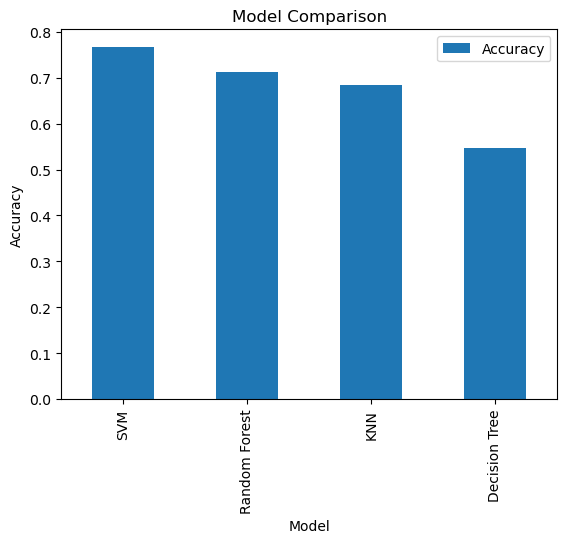

In [43]:
# Visualizations

import matplotlib.pyplot as plt

comparison.sort_values(
    by='Accuracy',
    ascending=False
).plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Model Comparison')
plt.ylabel('Accuracy')
plt.show()

In [44]:
# Feature Importance (Random Forest)

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
2,Low,0.154776
4,Volume,0.149876
0,Open,0.149832
1,High,0.139893
3,Close,0.136358
6,ZScore,0.135503
5,Return,0.133763


In [ ]:
# Important Observation

# All models are struggling to predict:

# High Risk (Class 0)
# Medium Risk (Class 1)

# and are mostly predicting:

# Low Risk (Class 2)

In [45]:
# As SVM has performed the best 

import joblib

joblib.dump(svm, 'stock_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print("Model Saved Successfully ")

Model Saved Successfully 


In [55]:
# Loading the Model

loaded_model = joblib.load('stock_risk_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

In [56]:
# Predicting Next Day Risk Class
# Latest data

latest_data = X.iloc[[-1]]

In [57]:
# Scaling it

latest_scaled = loaded_scaler.transform(latest_data)

In [58]:
# Prediciting
prediction = loaded_model.predict(latest_scaled)

print(prediction)

[2]


In [59]:
# Converting back to Labels

predicted_risk = le.inverse_transform(prediction)

print("Next Day Predicted Risk:", predicted_risk[0])

Next Day Predicted Risk: Medium Risk


In [60]:
# Feature Importance (Random Forest)
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

feature_importance.sort_values(
    by='Importance',
    ascending=False
)

,Feature,Importance
2,Low,0.154776
4,Volume,0.149876
0,Open,0.149832
1,High,0.139893
3,Close,0.136358
6,ZScore,0.135503
5,Return,0.133763


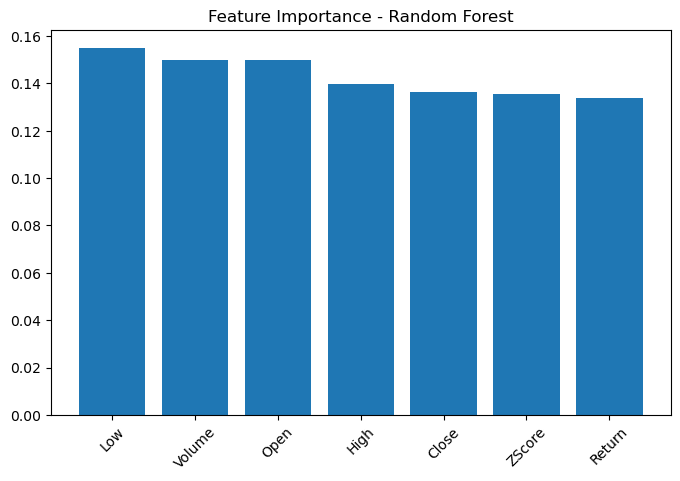

In [61]:
# Plotting the Feature Importance

import matplotlib.pyplot as plt

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.title('Feature Importance - Random Forest')
plt.xticks(rotation=45)
plt.show()

In [67]:
# Saving the Model 

import joblib

joblib.dump(svm, 'stock_risk_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le, 'label_encoder.pkl')

['label_encoder.pkl']

In [68]:
import os

print(os.listdir())

['.anaconda', '.android', '.atom', '.bash_history', '.conda', '.continuum', '.dbshell', '.emulator_console_auth_token', '.git-for-windows-updater', '.gitconfig', '.gradle', '.icesoft', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.m2', '.matplotlib', '.mongorc.js', '.ms-ad', '.nbi', '.packettracer', '.ssh', '.VirtualBox', '.vscode', '.zenmap', '3D Objects', 'Advance_python_session8_new.ipynb', 'Advance_Python_Session_7.ipynb', 'Advance_python_sesson8.ipynb', 'anaconda3', 'anaconda_projects', 'AndroidStudioProjects', 'AppData', 'Application Data', 'Capestone Project_1_Stock Analysis.ipynb', 'Capestone_Project_1.ipynb', 'Cast_Exercise_.ipynb', 'Cast_exercise_1.ipynb', 'Cast_exercise_1_sol.ipynb', 'Cast_Fully_Solved.ipynb', 'Chipotle_Exercise_sol.ipynb', 'Cisco Packet Tracer 7.3.0', 'Classification_Models.ipynb', 'clustering crime assignment_project.ipynb', 'Clustering_Airline_porject_assignment.ipynb', 'Company_Data_Random_Forest_Assignment_pro_Sol.ipynb', 'Contact

In [64]:
# predicting Next Day Risk
latest_data = X.iloc[[-1]]

latest_scaled = scaler.transform(latest_data)

prediction = svm.predict(latest_scaled)

predicted_class = le.inverse_transform(prediction)

print("Predicted Next Day Risk:", predicted_class[0])

Predicted Next Day Risk: Medium Risk


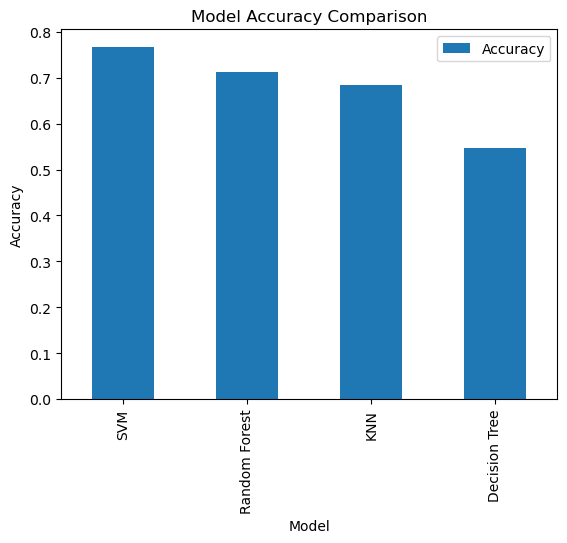

In [65]:
# Creating Accuracy Comparision Chart

comparison = pd.DataFrame({
    'Model':['KNN','Decision Tree','SVM','Random Forest'],
    'Accuracy':[0.6849,0.5479,0.7671,0.7123]
})

comparison.sort_values(
    by='Accuracy',
    ascending=False
).plot(
    x='Model',
    y='Accuracy',
    kind='bar'
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

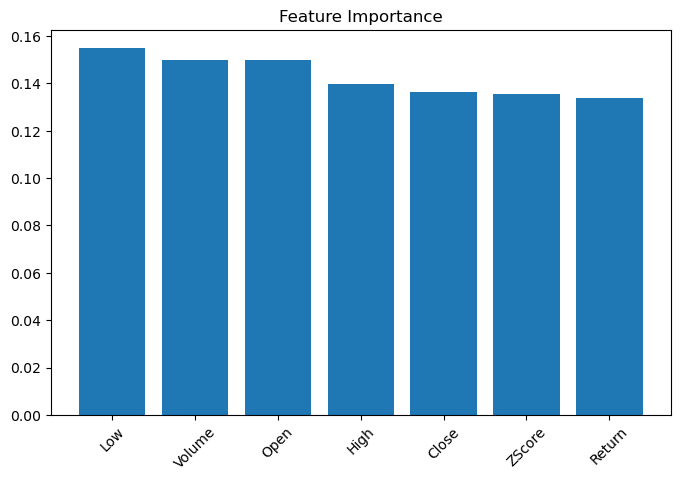

In [66]:
# Generating Feature Importance Plot

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(8,5))
plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.title('Feature Importance')
plt.xticks(rotation=45)
plt.show()